<a href="https://colab.research.google.com/github/Ali-AliAli-Ali/ML_homeworks_magistracy/blob/nlp/gpt_dev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дообучение модели GPT

Companion notebook to the [Zero To Hero](https://karpathy.ai/zero-to-hero.html) video on GPT.

### Информация о датасете

Дообучение производится на датасете [Russian songs (1800-1840ss)](https://github.com/perechen/russian.songs.final), содержащем данные о 527 русских песнях 1800-1840гг. Датасет содержит следующие файлы:
- таблицу с метаданными по русским песням за период 1800-1840гг, включающую:
    - `id` - идентификатор текста, для удобства ручной работы;
    - `name` - имя автора или подпись под публикацией;
    - `title` - первая строка стихотворения (без знаков препинания);
    - `publication` - первая публикация + дополнительные перепечатки + современные переиздания (если это источник текста в корпусе);
    - `year` - датировка стихотворения;
    - `g_title` - заголовок + подзаголовок стихотворения;
    - `comment` - дополнительные сведения о публикации (примечания, особенности, etc);
    - `pub_year` - год первой публикации текста;
    - `pub_type` - тип первой публикации - периодика (+альманахи) или другое (`collection` включает также случаи, когда песня была интегрирована в какое-нибудь большое произведение);
    - `meter` - метрическая формула;
    - `regularity` - регулярность метра;
    - `rhyme` - есть рифма или ее нет;
    - `type` - относится ли текст к ядру жанра (core) или нет (periph).
- архив с текстами корпуса в отдельных `.txt`-файлах. Номер файла с текстом соответствует id песни в таблице.


### Предобработка датасета

Загрузим тексты песен и объединим набор песен в единый `.txt`-файл для удобства обработки.

In [ ]:
!wget https://github.com/perechen/russian.songs.final/raw/refs/heads/master/corpus_split.zip
!file /content/corpus_split.zip

In [9]:
!unzip /content/corpus_split.zip
!rm /content/corpus_split.zip

In [1]:
songs_texts_file = "./corpus_split.txt"
songs_texts_dir = "./corpus_split"

In [65]:
import os
import shutil
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [ ]:
# write all songs texts into one .txt

with open(songs_texts_file, 'w', encoding='utf-8') as all_texts:
    for text_file in os.listdir(songs_texts_dir):
        if text_file.endswith(".txt"):
            with open(os.path.join(songs_texts_dir, text_file), 'r', encoding='utf-8') as text:
                all_texts.write(text.read())
                all_texts.write("\n===END===\n\n")
            print(f"Text from {text_file} written into {songs_texts_file}")

    print(f"\nAll songs texts are successfully written into {songs_texts_file}")

In [21]:
# read the result .txt in to inspect it

with open(songs_texts_file, 'r', encoding='utf-8') as all_texts:
    songs_texts = all_texts.read()
print("Dataset length in characters:", len(songs_texts))

Dataset length in characters: 324102


In [22]:
# examine the first 100 characters
print(songs_texts[3000:3300])

 богатством
Можно век провесть в слезах,
И при золоте
С печали умереть!
Не богатство нам,
А милый дорог друг,
И не золото,
А милого любовь.

===END===

много есть у мен¤
теремов и садов, 
и раздольных полей, 
и дремучих лесов. 

много есть у мен¤
деревень и людей, 
и знакомых бо¤р, 
и надежных друзе


In [23]:
# examine all the unique characters occuring in the text
symbols = sorted(list(set(songs_texts)))
vocab_size = len(symbols)
print("Vocabulary:", ' '.join(symbols))
print("Vocabulary size:", vocab_size)

Vocabulary: 	 
   ! " ( ) , - . : ; = ? D E N _   ¤ « ¬ » ƒ Ђ Ѕ Ћ Ќ А Б В Г Д Е Ж З И К Л М Н О П Р С Т У Ф Х Ц Ч Ш Щ Ы Э Ю Я а б в г д е ж з и й к л м н о п р с т у ф х ц ч ш щ ъ ы ь э ю я ё ѕ ї ј ћ – — ’ “ … ∆ √ ≈
Vocabulary size: 102


In [24]:
# clean up the dataset: replace symbols that are not 'E','N','D','=', russian letter or punctuation mark, with their modern analogies

songs_texts_clean_file = "./corpus_split_clean.txt"
shutil.copyfile(songs_texts_file, songs_texts_clean_file)

symbol_replace_map = {
    ' ? ': ' ',
    'Е ': '',
    '_': '',
    '¤': 'я',
    'ƒ': 'Д',
    'Ђ': '',
    'Ѕ': 'Б',
    'Ћ': 'л', 
    'Ќ': 'Н',
    '¬': 'В',
    'ѕ': 'П',
    'ї': '', 
    'ј': 'И', 
    'ћ': 'М',
    '’': 'Х',
    '“': 'Т',
    '∆': 'Ж',
    '√': 'Г', 
    '≈': 'Е'
}

with open(songs_texts_clean_file, 'r', encoding='utf-8') as all_texts_clean:
    songs_texts_clean = all_texts_clean.read()
for old_symbol, new_symbol in symbol_replace_map.items():
    songs_texts_clean = songs_texts_clean.replace(old_symbol, new_symbol)
with open(songs_texts_clean_file, 'w', encoding='utf-8') as all_texts_clean:
    all_texts_clean.write(songs_texts_clean)

In [25]:
# examine the new dataset and all the unique characters occuring in the text

songs_texts_clean_file = "./corpus_split_clean.txt"
with open(songs_texts_clean_file, 'r', encoding='utf-8') as all_texts_clean:
    songs_texts_clean = all_texts_clean.read()

print("Length of cleaned dataset in characters:", len(songs_texts_clean))
symbols = sorted(list(set(songs_texts_clean)))
vocab_size = len(symbols)
print("Vocabulary:", ' '.join(symbols))
print("Vocabulary size:", vocab_size)

Length of cleaned dataset in characters: 323878
Vocabulary: 	 
   ! " ( ) , - . : ; = ? D E N   « » А Б В Г Д Е Ж З И К Л М Н О П Р С Т У Ф Х Ц Ч Ш Щ Ы Э Ю Я а б в г д е ж з и й к л м н о п р с т у ф х ц ч ш щ ъ ы ь э ю я ё – — …
Vocabulary size: 85


### Подготовка данных к обучению

In [26]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(symbols) }
itos = { i:ch for i,ch in enumerate(symbols) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[int(i)] for i in l]) # decoder: take a list of integers, output a string

print(encode("Некоторая строка русских букав"))
print(decode(encode("Некоторая строка русских букав")))

[32, 54, 59, 63, 67, 63, 65, 49, 80, 2, 66, 67, 65, 63, 59, 49, 2, 65, 68, 66, 66, 59, 57, 70, 2, 50, 68, 59, 49, 51]
Некоторая строка русских букав


In [27]:
# encode the entire dataset and store it into a torch.Tensor
songs_enc = torch.tensor(encode(songs_texts_clean), dtype=torch.long)
print("Size and type of encoded dataset:", songs_enc.shape, songs_enc.dtype)

print("\n    The following text:")
print(songs_texts_clean[3000:3300])
print("\n    to the GPT will look like this:")
print(songs_enc[3000:3300])

Size and type of encoded dataset: torch.Size([323878]) torch.int64

    The following text:
 богатством
Можно век провесть в слезах,
И при золоте
С печали умереть!
Не богатство нам,
А милый дорог друг,
И не золото,
А милого любовь.

===END===

много есть у меня
теремов и садов, 
и раздольных полей, 
и дремучих лесов. 

много есть у меня
деревень и людей, 
и знакомых бояр, 
и надежных друзе

    to the GPT will look like this:
tensor([ 2, 50, 63, 52, 49, 67, 66, 67, 51, 63, 61,  1, 31, 63, 55, 62, 63,  2,
        51, 54, 59,  2, 64, 65, 63, 51, 54, 66, 67, 77,  2, 51,  2, 66, 60, 54,
        56, 49, 70,  7,  1, 28,  2, 64, 65, 57,  2, 56, 63, 60, 63, 67, 54,  1,
        36,  2, 64, 54, 72, 49, 60, 57,  2, 68, 61, 54, 65, 54, 67, 77,  3,  1,
        32, 54,  2, 50, 63, 52, 49, 67, 66, 67, 51, 63,  2, 62, 49, 61,  7,  1,
        20,  2, 61, 57, 60, 76, 58,  2, 53, 63, 65, 63, 52,  2, 53, 65, 68, 52,
         7,  1, 28,  2, 62, 54,  2, 56, 63, 60, 63, 67, 63,  7,  1, 20,  2, 61,
        57

In [28]:
# split up the data into train and validation sets
n = int(0.9*len(songs_enc)) # first 90% will be train, rest val
train_data = songs_enc[:n]
val_data = songs_enc[n:]

In [29]:
# set batch and block size
batch_size = 4 # number of independent sequences that will be processed in parallel
block_size = 8 # the maximum context length for predictions

print("The first block and value to predict:", train_data[:block_size+1])

The first block and value to predict: tensor([32, 54,  2, 51,  2, 72, 57, 66, 67])


In [30]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"When input is {context} the target is: {target}")

When input is tensor([32]) the target is: 54
When input is tensor([32, 54]) the target is: 2
When input is tensor([32, 54,  2]) the target is: 51
When input is tensor([32, 54,  2, 51]) the target is: 2
When input is tensor([32, 54,  2, 51,  2]) the target is: 72
When input is tensor([32, 54,  2, 51,  2, 72]) the target is: 57
When input is tensor([32, 54,  2, 51,  2, 72, 57]) the target is: 66
When input is tensor([32, 54,  2, 51,  2, 72, 57, 66]) the target is: 67


In [ ]:
torch.manual_seed(42)

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"When input is {context.tolist()} the target is: {target}")

inputs:
torch.Size([4, 8])
tensor([[77,  2, 67, 54, 50, 54,  2, 61],
        [76,  7,  2, 33, 65, 60, 76,  2],
        [66, 67, 49, 51, 73, 57,  7,  2],
        [53, 63, 60, 57, 62, 54,  2, 67]])
targets:
torch.Size([4, 8])
tensor([[ 2, 67, 54, 50, 54,  2, 61, 63],
        [ 7,  2, 33, 65, 60, 76,  2, 36],
        [67, 49, 51, 73, 57,  7,  2, 64],
        [63, 60, 57, 62, 54,  2, 67, 63]])
----
When input is [77] the target is: 2
When input is [77, 2] the target is: 67
When input is [77, 2, 67] the target is: 54
When input is [77, 2, 67, 54] the target is: 50
When input is [77, 2, 67, 54, 50] the target is: 54
When input is [77, 2, 67, 54, 50, 54] the target is: 2
When input is [77, 2, 67, 54, 50, 54, 2] the target is: 61
When input is [77, 2, 67, 54, 50, 54, 2, 61] the target is: 63
When input is [76] the target is: 7
When input is [76, 7] the target is: 2
When input is [76, 7, 2] the target is: 33
When input is [76, 7, 2, 33] the target is: 65
When input is [76, 7, 2, 33, 65] the tar

In [32]:
print(xb) # input to the transformer
print([decode(row) for row in xb])

tensor([[77,  2, 67, 54, 50, 54,  2, 61],
        [76,  7,  2, 33, 65, 60, 76,  2],
        [66, 67, 49, 51, 73, 57,  7,  2],
        [53, 63, 60, 57, 62, 54,  2, 67]])
['ь тебе м', 'ы, Орлы ', 'ставши, ', 'долине т']


### Создание и обучение примитивной модели

In [84]:
torch.manual_seed(42)

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

bilang_model = BigramLanguageModel(vocab_size)
logits, loss = bilang_model(xb, yb)
print("Logits tensor dimensions:", logits.shape)
print("Loss before training:", loss)

print("Generation before training:")
print(decode(bilang_model.generate(idx = torch.zeros((1, 1), dtype=torch.long), 
                                   max_new_tokens=100)[0].tolist()))

Logits tensor dimensions: torch.Size([256, 85])
Loss before training: tensor(4.7939, grad_fn=<NllLossBackward0>)
Generation before training:
	рж,ДщСДЕРчфДавЗпЖЗ—СEЩх:–-зБъУцэяЗЛЕ.уАнны«—чкКгйсЯдпфаРл	.ВЮБсЕ-в…?ОЯяЕГХДа;фыДу–DшмМГэ–ТЧ=УЕщ?гаъ.


In [85]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(bilang_model.parameters(), lr=1e-3)

In [ ]:
batch_size = 32
losses = []

for steps in range(10000): # increase number of steps for good results
    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = bilang_model(xb, yb)  #m(xb, yb)
    losses.append(loss.item())
    
    # backpropagation
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

In [91]:
print("Resulting loss is: ", loss.item())
print("The least loss was:", min(losses))

Resulting loss is:  2.6061418056488037
The least loss was: 2.288738965988159


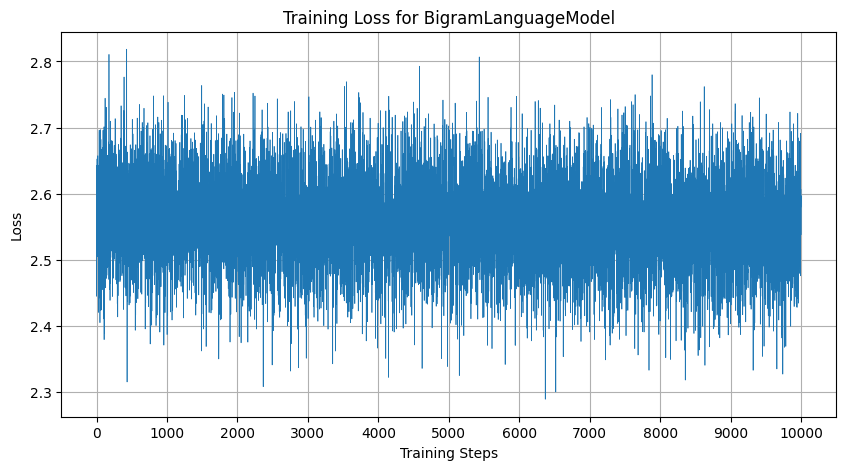

In [92]:
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=0.5)
plt.grid(True)
plt.xticks([i * 1000 for i in range(11)])

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss for BigramLanguageModel")
plt.show()

In [93]:
print(decode(bilang_model.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=500)[0].tolist()))

	прышебя х
Тая, дой звушкрадозой Гове

В  пцу дролюсвуй ценовни.
Ахушая  ни ре раска свосью касоск т пото 
Охоте 
суноных куся?
побылевяныте Повдкрадру;
Налезакапой,

Вивис г умою лгро пловеся гой л; Чт жнаторвлна
А хиж кудне т мазакроютой в сь, водологодигриламудирдце нятам  рас г оглье 
 гдвену?
Я б сят поныецадема езвей! овнносолы з гом ноя млидра давумелате гот ебицулолаве вро ль, к: тух! левиротый,
Вд олей,
Воетнера чу,
Чтрдтила пезбено,
Уве  сларетгадвай мо н дегл тоючнестый.
Ах
Кре пчь вок


## Дообучение модели GPT

### The mathematical trick in self-attention

In [94]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
torch.manual_seed(42)

a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [95]:
# consider the following toy example:

torch.manual_seed(42)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [ ]:
# We want x[b,t] = mean_{i<=t} x[b,i]

xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow[b,t] = torch.mean(xprev, 0)

In [97]:
# version 2: using matrix multiply for a weighted aggregation

wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
torch.allclose(xbow, xbow2)

True

In [99]:
# version 3: use Softmax

tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x
torch.allclose(xbow, xbow3)

True

In [100]:
# version 4: self-attention!

torch.manual_seed(42)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
#out = wei @ x

out.shape

torch.Size([4, 8, 16])

In [101]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1905, 0.8095, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3742, 0.0568, 0.5690, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1288, 0.3380, 0.1376, 0.3956, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4311, 0.0841, 0.0582, 0.3049, 0.1217, 0.0000, 0.0000, 0.0000],
        [0.0537, 0.3205, 0.0694, 0.2404, 0.2568, 0.0592, 0.0000, 0.0000],
        [0.3396, 0.0149, 0.5165, 0.0180, 0.0658, 0.0080, 0.0373, 0.0000],
        [0.0165, 0.0375, 0.0144, 0.1120, 0.0332, 0.4069, 0.3136, 0.0660]],
       grad_fn=<SelectBackward0>)

Notes:
- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talk" to each other
- In an "encoder" attention block just delete the single line that does masking with `tril`, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modeling.
- "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source (e.g. an encoder module)
- "Scaled" attention additional divides `wei` by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

In [105]:
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

print("Variation of K:", k.var().item())
print("Variation of Q:", q.var().item())
print("Variation of W:", wei.var().item())

Variation of K: 0.9592004418373108
Variation of Q: 0.9620750546455383
Variation of W: 0.9678049087524414


In [107]:
print(torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5]), dim=-1))
print(torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5]) * T, dim=-1)) # gets too peaky, converges to one-hot

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


In [ ]:
class LayerNorm1d: # (used to be BatchNorm1d)

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    # calculate the forward pass
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

torch.manual_seed(42)
module = LayerNorm1d(100)
x = torch.randn(32, 100) # batch size 32 of 100-dimensional vectors
x = module(x)
x.shape

torch.Size([32, 100])

In [110]:
print("Mean and std of one feature across all batch inputs:          ", x[:,0].mean(), x[:,0].std())
print("Mean and std of single input from the batch, of its features: ", x[0,:].mean(), x[0,:].std())

Mean and std of one feature across all batch inputs:           tensor(-0.0468) tensor(1.0733)
Mean and std of single input from the batch, of its features:  tensor(0.0630) tensor(0.9888)


## Дообучение модели GPT

In [115]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

In [111]:
# functions

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [113]:
# classes

class Head(nn.Module):
    """ One head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ Multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    """ Simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class BigramLanguageModel(nn.Module):
    """ Super simple bigram model """

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

In [ ]:
torch.manual_seed(42)

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel
block_size = 32 # the maximum context length for predictions
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = "cuda" if torch.cuda.is_available() else "cpu"
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0


# Dataset processing

songs_file = "./corpus_split_clean.txt"
with open(songs_file, 'r', encoding='utf-8') as all_texts:
    songs = all_texts.read()
print("Texts read from file")

# gather the unique characters occurring in the text
vocab = sorted(list(set(songs)))
vocab_size = len(vocab)
# create a mapping from characters to integers
stoi = { ch:i for i, ch in enumerate(vocab) }
itos = { i:ch for i, ch in enumerate(vocab) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[int(i)] for i in l]) # decoder: take a list of integers, output a string
print("Texts encoded, mappings created")

# Train and val splits

data = torch.tensor(encode(songs), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# Train model

model = BigramLanguageModel().to(device)
print("The model includes", sum(param.numel() for param in model.parameters())/1e6, 'M parameters')

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
loss_dynamics = []

for iter in range(max_iters):
    # every once in a while evaluate the loss on train and val sets
    if (not iter % eval_interval) or (iter == max_iters - 1):
        losses = estimate_loss()
        print(f"Step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    loss_dynamics.append(loss.item())

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

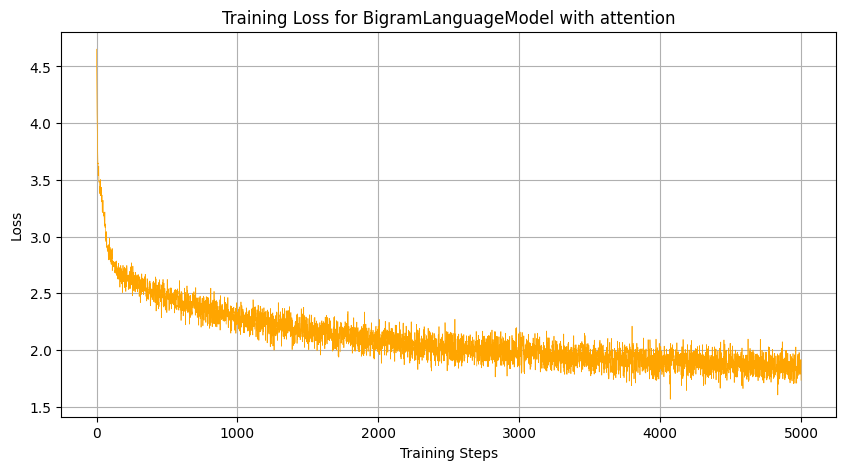

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(loss_dynamics, linewidth=0.5, color="orange")
plt.grid(True)

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss for BigramLanguageModel with attention")
plt.show()

In [ ]:
# generate from the model

# context = torch.zeros((1, 1), dtype=torch.long, device=device)
context_str = "Выйду ночью в поле с конем"
context = torch.tensor((encode(context_str[ : len(context_str)//2]), 
                        encode(context_str[len(context_str)//2 : ])), 
                       dtype=torch.long, 
                       device=device)

print("Context: ", context_str)
print(context, "\n")
print(decode(model.generate(context, max_new_tokens=2000)[0].tolist()))

Context:  Выйду ночью в поле с конем
tensor([[22, 76, 58, 53, 68,  2, 62, 63, 72, 77, 79,  2, 51],
        [ 2, 64, 63, 60, 54,  2, 66,  2, 59, 63, 62, 54, 61]])
Выйду ночью вяжет, 
мило плывалься в манет,
Не чего о объю плесабви, 
«и повет – солнце леть матенькам?

Ну долько грому к лижка согазьта; 
ну любит грусти, покой свре не на с душа по мопецк вермок мояся?
Утри ливородаряньет разыщаюх
Под тонется:
Буде не ты самывали.
Вот убо к овозой веку
От чемове
От себе ли мое с идруку!
Но окрасное ботаме звездочь,
По нем цалостие,
 Я в бар, он одновою
Казвод облы мечто,
Не отчем по лесу ярем...
Ах неже день мою добровню,
Ты не могиня без коньца душа здо куть,
На злою дороге мне швета цвенок поле. 

чашным голубвивый
    Мне в гляни
В выровамо
Зад воим и за измянушкап?
Что я чуках лишь лежить не не ты отрила,
А не шатом в порхолюшил и я вором
И уж я тоскуя пырал;
Что придарь любедко,
А гнем мой расдится…
Как и я гучем, нели век игратя;
- Давалися, не знается и может,-
Лышу я твой лышет, что